Analyze 1.5 million real US domestic flight records to identify the root causes of delays, evaluate airline performance, and uncover operational bottlenecks.

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:

airlines_path = '/kaggle/input/datasets/organizations/usdot/flight-delays/airlines.csv'
flights_path = '/kaggle/input/datasets/organizations/usdot/flight-delays/flights.csv'


airlines_df = pd.read_csv(airlines_path)

# Load flights data (first 1.5 million rows)
print("Loading flights data (this takes ~20 seconds)...")
flights_df = pd.read_csv(flights_path, nrows=1500000)
print("Data loaded successfully! Shape:", flights_df.shape)

Loading flights data (this takes ~20 seconds)...
Data loaded successfully! Shape: (1500000, 31)


Data Cleaning & Feature Engineering
Filling missing delay reasons with 0 (NaN means no delay occurred).
Creating an IS_DELAYED flag (FAA defines a delay as > 15 minutes).
Mapping Airline codes to readable names.
Extracting the scheduled hour of departure to analyze daily trends.

In [8]:
# Replace NaN in delay reason columns with 0
delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
for col in delay_cols:
    if col in flights_df.columns:
        flights_df[col] = flights_df[col].fillna(0)

# Create 'IS_DELAYED' column
flights_df['IS_DELAYED'] = (flights_df['DEPARTURE_DELAY'] > 15).astype(int)

# Merge airline names
flights_df = flights_df.merge(airlines_df, left_on='AIRLINE', right_on='IATA_CODE', how='left')
flights_df.rename(columns={'AIRLINE_x': 'AIRLINE_CODE', 'AIRLINE_y': 'AIRLINE_NAME'}, inplace=True)

# Extract hour from scheduled departure (format is HHMM, e.g., 530 = 5:30 AM)
flights_df['SCHEDULED_HOUR'] = (flights_df['SCHEDULED_DEPARTURE'] // 100).clip(upper=23)

print("Data preparation complete.")

Data preparation complete.


Root Cause Analysis
What is actually causing these delays? We filter for delayed flights and sum up the total minutes attributed to each cause.

/tmp/ipykernel_58/1923586447.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_causes.values, y=delay_causes.index, palette='Reds_r')


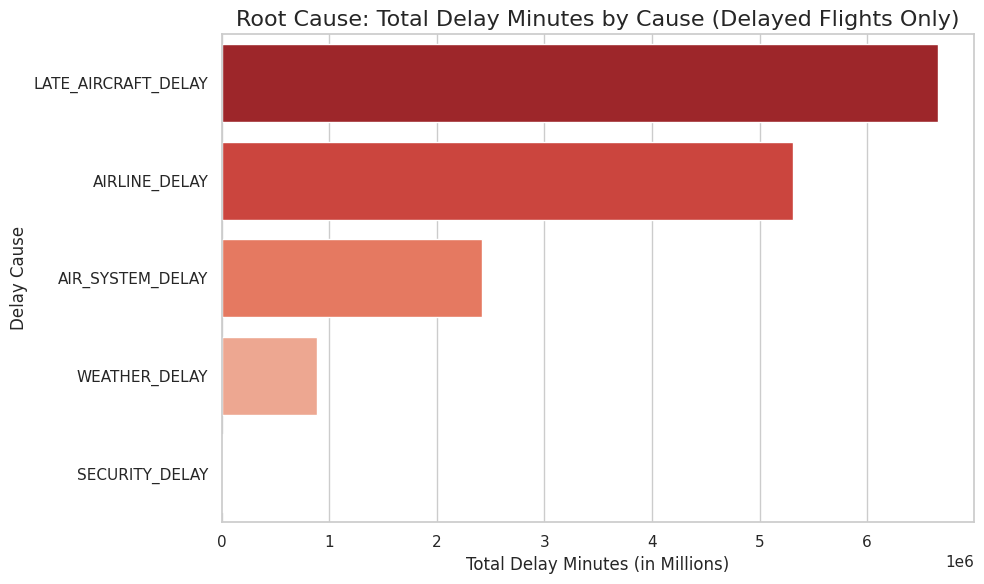

In [9]:
# Filter only delayed flights
delayed_flights = flights_df[flights_df['IS_DELAYED'] == 1].copy()

# Sum total minutes for each delay reason
delay_causes = delayed_flights[delay_cols].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=delay_causes.values, y=delay_causes.index, palette='Reds_r')
plt.title('Root Cause: Total Delay Minutes by Cause (Delayed Flights Only)', fontsize=16)
plt.xlabel('Total Delay Minutes (in Millions)', fontsize=12)
plt.ylabel('Delay Cause', fontsize=12)
plt.tight_layout()
plt.show()

Airline Performance Comparison
Which airlines are structurally better at operations? We calculate the average departure delay per airline

/tmp/ipykernel_58/2307195185.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_perf.values, y=airline_perf.index, palette='coolwarm')


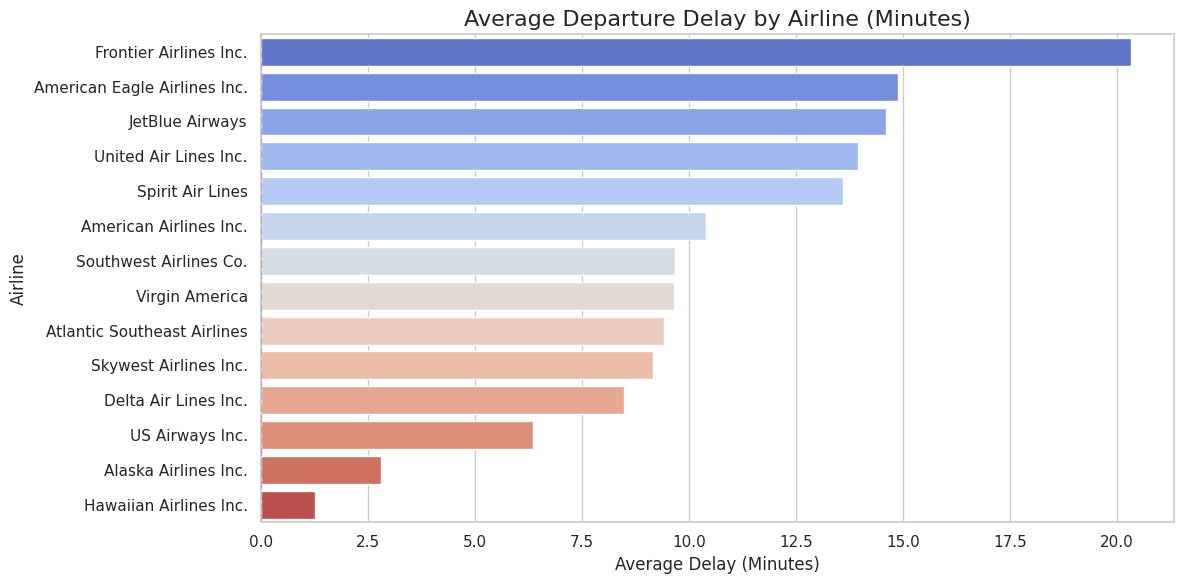

In [10]:
# Calculate average departure delay by airline
airline_perf = flights_df.groupby('AIRLINE_NAME')['DEPARTURE_DELAY'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=airline_perf.values, y=airline_perf.index, palette='coolwarm')
plt.title('Average Departure Delay by Airline (Minutes)', fontsize=16)
plt.xlabel('Average Delay (Minutes)', fontsize=12)
plt.ylabel('Airline', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

The "Ripple Effect" (Time of Day Analysis)
Do morning flights fare better than evening flights? We group by the scheduled departure hour to see how delays compound throughout the day

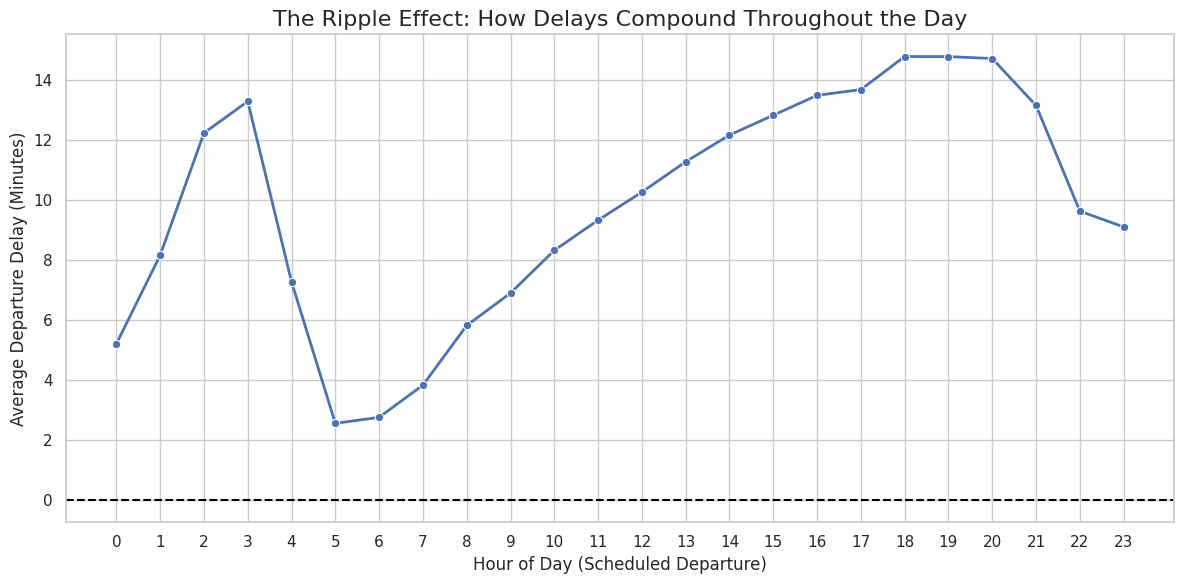

In [11]:
# Group by scheduled hour and calculate average departure delay
hourly_delay = flights_df.groupby('SCHEDULED_HOUR')['DEPARTURE_DELAY'].mean()


plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_delay.index, y=hourly_delay.values, marker='o', color='b', linewidth=2)
plt.title('The Ripple Effect: How Delays Compound Throughout the Day', fontsize=16)
plt.xlabel('Hour of Day (Scheduled Departure)', fontsize=12)
plt.ylabel('Average Departure Delay (Minutes)', fontsize=12)
plt.xticks(range(0, 24))
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

Worst Performing Airports
Which airports have the worst departure delays? We filter for major airports (>1,000 flights in our dataset) to find the top 10 bottlenecks.

/tmp/ipykernel_58/689870933.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airport_perf.values, y=airport_perf.index, palette='Oranges_r')


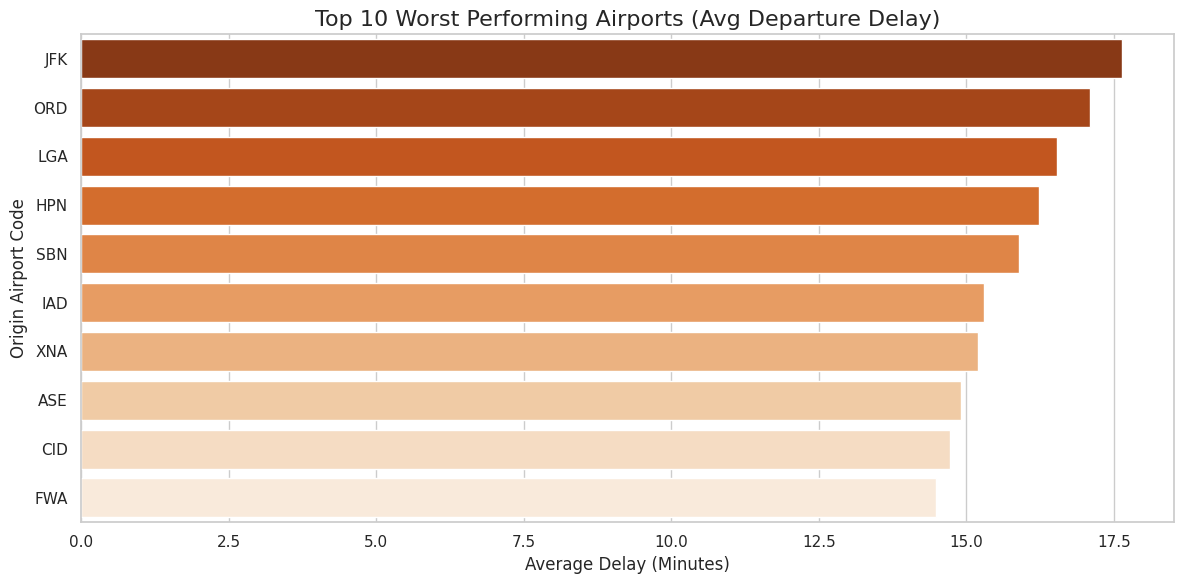

In [12]:
# Filter for major airports to avoid skewed data from tiny airports
airport_counts = flights_df['ORIGIN_AIRPORT'].value_counts()
major_airports = airport_counts[airport_counts > 1000].index

# Calculate average delay and get top 10 worst
airport_perf = flights_df[flights_df['ORIGIN_AIRPORT'].isin(major_airports)] \
                .groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean() \
                .sort_values(ascending=False).head(10)


plt.figure(figsize=(12, 6))
sns.barplot(x=airport_perf.values, y=airport_perf.index, palette='Oranges_r')
plt.title('Top 10 Worst Performing Airports (Avg Departure Delay)', fontsize=16)
plt.xlabel('Average Delay (Minutes)', fontsize=12)
plt.ylabel('Origin Airport Code', fontsize=12)
plt.tight_layout()
plt.show()

Insights:

Late Aircraft is the Biggest Culprit: Late arriving aircraft and internal airline operations account for the vast majority of delay minutes, far outweighing weather or security.
The "Ripple Effect" is Real: Flights scheduled between 5:00 AM and 7:00 AM experience almost zero delays. Delays compound exponentially after 2:00 PM.
Airline Choice Matters: Some airlines structurally handle operations better. Hawaiian and Alaska Airlines maintain low average delays, while others average significantly higher delay times.